
# Fundamentals of Natural Language - Project Follow-up  
## Exploratory Data Analysis and first method proposal  
**Students:** Phoebe Iglesias, David Redrejo & Pau Rossell

This notebook is written as a **computational narrative**: each section explains **why** we do a given analysis, **what** we observe, and **how** that changes the next step. The goal is not only to show plots, but to make the EDA itself work as a clear answer for the first follow-up.

### What the follow-up asks us to demonstrate
From the project brief, the first follow-up should show that we have:
1. understood the task, the dataset and the annotation format,
2. analyzed the data and the annotations,
3. identified the main challenges,
4. reviewed suitable reference methods, and
5. arrived at a justified first proposal.

### Working hypothesis
From the files we received, the project is **not** a full-document ICD coding task like MIMIC or CodiEsp.  
Instead, it looks like a **clinical term / literal codification** problem:

- `codification_data.csv`: supervised pairs `(Code, Literal)` that we can use for training,
- `leaderboard_data.csv`: literals without codes, presumably the evaluation or submission side,
- `icd_d_p_pairs.csv`: a much larger catalog of ICD codes and official descriptions.

So our first job is to verify whether that interpretation is correct, and then study what kind of modeling problem this creates.


In [1]:

import warnings, re, unicodedata, math, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = "data"

leaderboard = pd.read_csv(f"{DATA_DIR}/leaderboard_data.csv")
codification = pd.read_csv(f"{DATA_DIR}/codification_data.csv")
icd_catalog = pd.read_csv(f"{DATA_DIR}/icd_d_p_pairs.csv")

def normalize_text(text: str) -> str:
    text = str(text).strip().lower()
    text = "".join(
        ch for ch in unicodedata.normalize("NFD", text)
        if unicodedata.category(ch) != "Mn"
    )
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def add_surface_features(df, text_col):
    out = df.copy()
    s = out[text_col].astype(str)
    out["norm"] = s.map(normalize_text)
    out["n_chars"] = s.str.len()
    out["n_tokens"] = s.str.split().str.len()
    out["has_digit"] = s.str.contains(r"\d", regex=True)
    out["has_punct"] = s.str.contains(r"[^\w\s]", regex=True)
    out["is_all_upper"] = s.str.fullmatch(r"[^a-záéíóúüñ]*[A-ZÁÉÍÓÚÜÑ][^a-záéíóúüñ]*", na=False)
    out["has_accent"] = s.map(lambda x: any("WITH" in unicodedata.name(ch, "") for ch in x if ch.isalpha()))
    return out

leaderboard = add_surface_features(leaderboard, "Literal")
codification = add_surface_features(codification, "Literal")
icd_catalog = add_surface_features(icd_catalog, "Description")

display(leaderboard.head())
display(codification.head())
display(icd_catalog.head())


,id,Literal,norm,n_chars,n_tokens,has_digit,has_punct,is_all_upper,has_accent
0,1,AMNIODRENAJE,amniodrenaje,12,1,False,False,True,False
1,2,Hiperparatiroidismo primario,hiperparatiroidismo primario,28,2,False,False,False,False
2,3,MIGRANYA parto,migranya parto,14,2,False,False,False,False
3,4,VHC,vhc,3,1,False,False,True,False
4,5,Absceso mama izq,absceso mama izq,16,3,False,False,False,False


,Code,Literal,norm,n_chars,n_tokens,has_digit,has_punct,is_all_upper,has_accent
0,J9809,Hiperreactividad bronquial,hiperreactividad bronquial,26,2,False,False,False,False
1,J9801,broncoespástica,broncoespastica,15,1,False,False,False,True
2,I420,miocardiopatía dilatada,miocardiopatia dilatada,23,2,False,False,False,True
3,Y831,HTA irc 6,hta irc 6,9,3,True,False,False,False
4,R5600,Crisis febriles atípicas,crisis febriles atipicas,24,3,False,False,False,True


,Code,D_P,Description,norm,n_chars,n_tokens,has_digit,has_punct,is_all_upper,has_accent
0,A00,D,Cólera,colera,6,1,False,False,False,True
1,A000,D,"Cólera debido a Vibrio cholerae 01, biotipo ch...",colera debido a vibrio cholerae 01 biotipo cho...,52,8,True,True,False,True
2,A001,D,"Cólera debido a Vibrio cholerae 01, biotipo El...",colera debido a vibrio cholerae 01 biotipo el tor,50,9,True,True,False,True
3,A009,D,"Cólera, no especificado",colera no especificado,23,3,False,True,False,True
4,A01,D,Fiebres tifoidea y paratifoidea,fiebres tifoidea y paratifoidea,31,4,False,False,False,False



## 1. First sanity check: what is each file doing?

Before thinking about models, we need to make sure we understand the role of each dataset.  
A small structural summary already tells us a lot.


In [2]:

summary = pd.DataFrame([
    {
        "dataset": "leaderboard_data",
        "rows": len(leaderboard),
        "columns": ", ".join(leaderboard.columns[:2]),
        "unique_codes": np.nan,
        "unique_literals_or_desc": leaderboard["Literal"].nunique(),
    },
    {
        "dataset": "codification_data",
        "rows": len(codification),
        "columns": ", ".join(codification.columns[:2]),
        "unique_codes": codification["Code"].nunique(),
        "unique_literals_or_desc": codification["Literal"].nunique(),
    },
    {
        "dataset": "icd_d_p_pairs",
        "rows": len(icd_catalog),
        "columns": ", ".join(icd_catalog.columns[:3]),
        "unique_codes": icd_catalog["Code"].nunique(),
        "unique_literals_or_desc": icd_catalog["Description"].nunique(),
    },
])
display(summary)


,dataset,rows,columns,unique_codes,unique_literals_or_desc
0,leaderboard_data,6667,"id, Literal",NaN,6102
1,codification_data,13700,"Code, Literal",4059.0,11584
2,icd_d_p_pairs,179742,"Code, D_P, Description",179742.0,174648



### Interpretation

This confirms the basic picture:

- `leaderboard_data` has only `id` and `Literal`: this looks like **input we must predict for**.
- `codification_data` contains supervised `(Code, Literal)` pairs: this is our **main training resource**.
- `icd_d_p_pairs` is much larger and contains `(Code, D_P, Description)`: this behaves like an **external terminology catalog**.

Now that we know the file roles, the next question is: **how well do these three resources connect to each other?**  
That matters because it tells us whether a simple dictionary approach is enough, or whether we need real generalization.


In [3]:

leaderboard_exact_in_train = leaderboard["Literal"].isin(set(codification["Literal"])).mean()
leaderboard_norm_in_train = leaderboard["norm"].isin(set(codification["norm"])).mean()

cod_with_catalog = codification["Code"].isin(set(icd_catalog["Code"])).mean()
exact_train_literal_in_catalog_desc = codification["Literal"].isin(set(icd_catalog["Description"])).mean()
norm_train_literal_in_catalog_desc = codification["norm"].isin(set(icd_catalog["norm"])).mean()

connection = pd.DataFrame({
    "check": [
        "Leaderboard literal exactly seen in training literals",
        "Leaderboard literal seen after normalization",
        "Training code present in ICD catalog",
        "Training literal exactly matches ICD official description",
        "Training literal matches ICD description after normalization",
    ],
    "share": [
        leaderboard_exact_in_train,
        leaderboard_norm_in_train,
        cod_with_catalog,
        exact_train_literal_in_catalog_desc,
        norm_train_literal_in_catalog_desc,
    ]
})
display(connection.style.format({"share": "{:.1%}"}))


,check,share
0,Leaderboard literal exactly seen in training literals,27.2%
1,Leaderboard literal seen after normalization,61.5%
2,Training code present in ICD catalog,72.6%
3,Training literal exactly matches ICD official description,2.0%
4,Training literal matches ICD description after normalization,5.6%



## 2. What this already tells us

This is one of the most important checkpoints in the notebook.

### Observation 1: exact repetition exists, but it is not enough
A non-trivial fraction of leaderboard literals already appear in the supervised training literals.  
That means an **exact-match baseline** is mandatory.

### Observation 2: normalization helps, but does not solve the problem
The overlap grows after lowercasing, accent removal and punctuation simplification, which means that **surface variation is real**.  
So text normalization is not optional preprocessing; it is part of the method.

### Observation 3: the ICD catalog is useful, but not directly aligned
A good amount of training codes exist in the catalog, but literal strings rarely match the official descriptions exactly.  
That means the catalog is valuable as **knowledge**, but not as a drop-in replacement for training data.

So the next thing we need to understand is **what kind of text variation we actually have**.



## 3. Surface form analysis

We now analyze the literals themselves.

Why do this now? Because before choosing a model, we need to know whether the task mostly depends on:

- short lexical similarity,
- abbreviations,
- punctuation and digits,
- accent and casing variation,
- or long contextual meaning.

If the inputs are very short and noisy, classical lexical models can be surprisingly competitive.


In [4]:

surface_stats = pd.DataFrame([
    {
        "dataset": "leaderboard literals",
        "mean chars": leaderboard["n_chars"].mean(),
        "mean tokens": leaderboard["n_tokens"].mean(),
        "contains digit": leaderboard["has_digit"].mean(),
        "contains punctuation": leaderboard["has_punct"].mean(),
        "all uppercase": leaderboard["is_all_upper"].mean(),
        "contains accent": leaderboard["has_accent"].mean(),
    },
    {
        "dataset": "training literals",
        "mean chars": codification["n_chars"].mean(),
        "mean tokens": codification["n_tokens"].mean(),
        "contains digit": codification["has_digit"].mean(),
        "contains punctuation": codification["has_punct"].mean(),
        "all uppercase": codification["is_all_upper"].mean(),
        "contains accent": codification["has_accent"].mean(),
    },
    {
        "dataset": "ICD official descriptions",
        "mean chars": icd_catalog["n_chars"].mean(),
        "mean tokens": icd_catalog["n_tokens"].mean(),
        "contains digit": icd_catalog["has_digit"].mean(),
        "contains punctuation": icd_catalog["has_punct"].mean(),
        "all uppercase": icd_catalog["is_all_upper"].mean(),
        "contains accent": icd_catalog["has_accent"].mean(),
    },
])

display(surface_stats.style.format({
    "mean chars": "{:.2f}",
    "mean tokens": "{:.2f}",
    "contains digit": "{:.1%}",
    "contains punctuation": "{:.1%}",
    "all uppercase": "{:.1%}",
    "contains accent": "{:.1%}",
}))


,dataset,mean chars,mean tokens,contains digit,contains punctuation,all uppercase,contains accent
0,leaderboard literals,17.15,2.22,7.6%,9.0%,11.3%,29.6%
1,training literals,16.95,2.21,8.0%,9.8%,11.8%,28.0%
2,ICD official descriptions,80.88,10.77,2.9%,85.3%,0.0%,85.7%


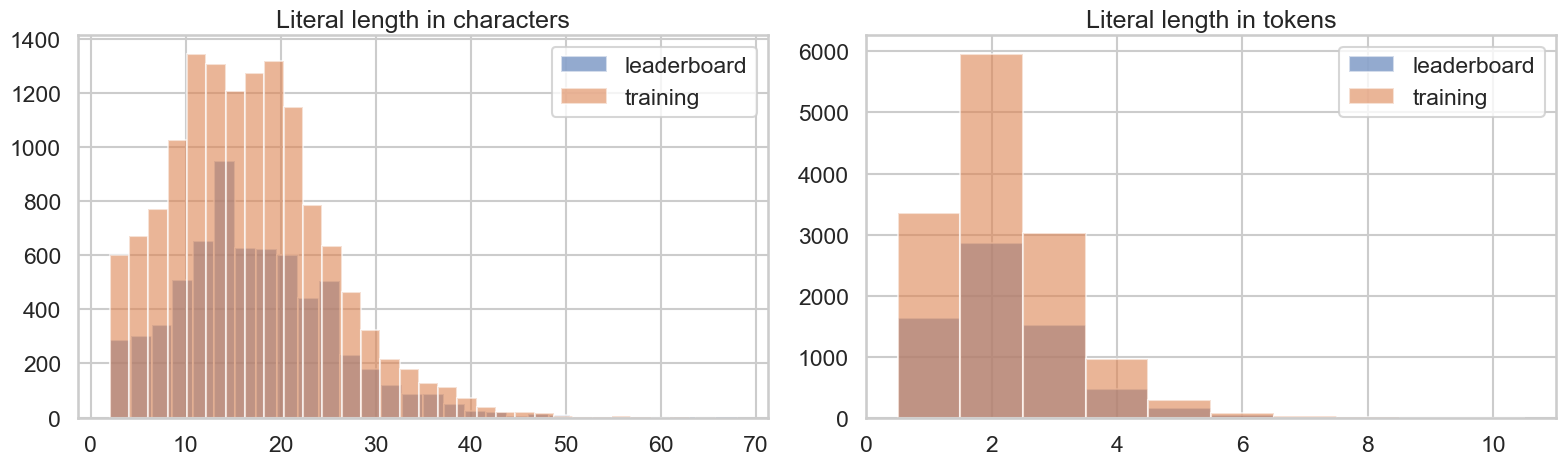

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(leaderboard["n_chars"], bins=30, alpha=0.6, label="leaderboard")
axes[0].hist(codification["n_chars"], bins=30, alpha=0.6, label="training")
axes[0].set_title("Literal length in characters")
axes[0].legend()

token_bins = np.arange(1, 12) - 0.5
axes[1].hist(leaderboard["n_tokens"], bins=token_bins, alpha=0.6, label="leaderboard")
axes[1].hist(codification["n_tokens"], bins=token_bins, alpha=0.6, label="training")
axes[1].set_title("Literal length in tokens")
axes[1].legend()

plt.tight_layout()
plt.show()


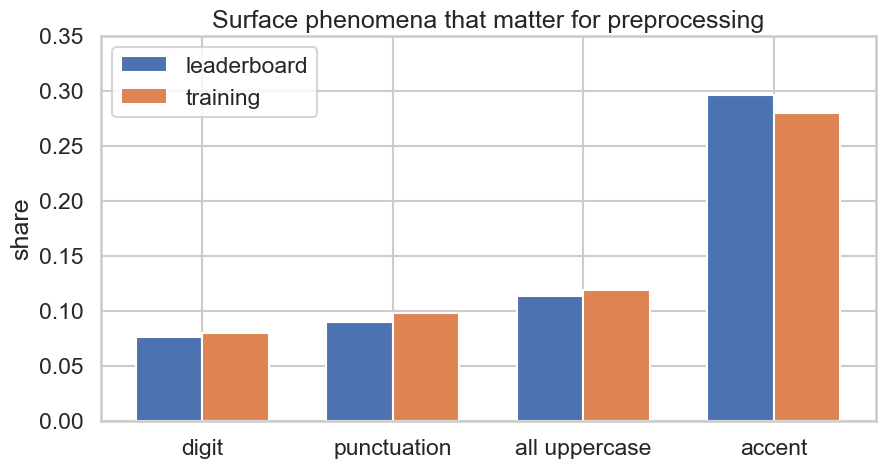

In [6]:

leader_vals = [
    leaderboard["has_digit"].mean(),
    leaderboard["has_punct"].mean(),
    leaderboard["is_all_upper"].mean(),
    leaderboard["has_accent"].mean(),
]
train_vals = [
    codification["has_digit"].mean(),
    codification["has_punct"].mean(),
    codification["is_all_upper"].mean(),
    codification["has_accent"].mean(),
]
features = ["digit", "punctuation", "all uppercase", "accent"]
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, leader_vals, width, label='leaderboard')
plt.bar(x + width/2, train_vals, width, label='training')
plt.xticks(x, features)
plt.ylim(0, 0.35)
plt.ylabel('share')
plt.title('Surface phenomena that matter for preprocessing')
plt.legend()
plt.show()



### What we learn from the surface analysis

The literals are **short**: around two tokens on average.  
That is a strong clue. This is much closer to **term normalization / label linking** than to long clinical-document coding.

This matters because:

- models that depend on long context are less relevant at this stage,
- character-level similarity becomes much more important,
- abbreviations and spelling variation can dominate performance,
- preprocessing choices can have a large effect.

So the next step is to ask a more difficult question:  
**does one literal correspond to one code, or are there ambiguities?**



## 4. Ambiguity and synonymy

This section is essential for deciding whether the task is mainly:

- dictionary lookup,
- multi-class classification,
- candidate retrieval,
- or a combination.

We compute two complementary views:

1. **Literal -> how many different codes?**  
   This measures ambiguity.
2. **Code -> how many different literals?**  
   This measures synonymy / paraphrasing.


NameError: name 'literal_to_n_codes' is not defined

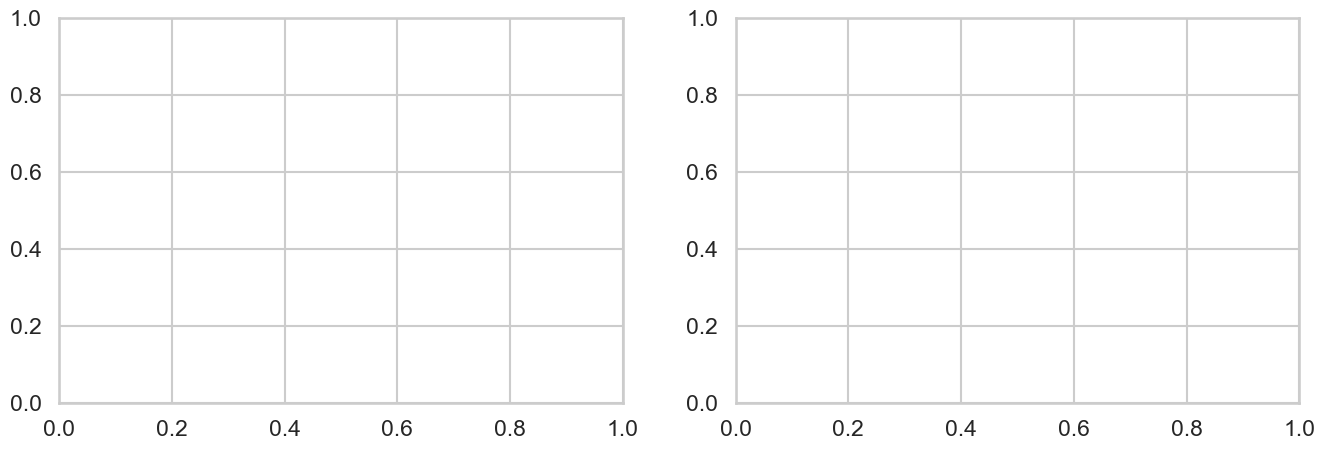

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

literal_to_n_codes.value_counts().sort_index().head(10).plot(kind="bar", ax=axes[0])
axes[0].set_title("How many codes can one literal map to?")
axes[0].set_xlabel("# codes for one literal")
axes[0].set_ylabel("# literals")

code_to_n_literals.value_counts().sort_index().head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("How many literals can describe one code?")
axes[1].set_xlabel("# literals for one code")
axes[1].set_ylabel("# codes")

plt.tight_layout()
plt.show()


In [8]:

ambiguous_examples = (
    codification.groupby("Literal")["Code"].nunique()
    .sort_values(ascending=False)
    .head(8)
    .index
)
display(
    codification[codification["Literal"].isin(ambiguous_examples)]
    .sort_values(["Literal", "Code"])
    .head(40)
)


,Code,Literal,norm,n_chars,n_tokens,has_digit,has_punct,is_all_upper,has_accent
2411,64891,Asma parto,asma parto,10,2,False,False,False,False
9470,E6601,Asma parto,asma parto,10,2,False,False,False,False
12338,F1011,Asma parto,asma parto,10,2,False,False,False,False
2652,I340,Asma parto,asma parto,10,2,False,False,False,False
5282,J45909,Asma parto,asma parto,10,2,False,False,False,False
7033,J8410,Asma parto,asma parto,10,2,False,False,False,False
920,J9811,Asma parto,asma parto,10,2,False,False,False,False
5110,O99314,Asma parto,asma parto,10,2,False,False,False,False
8841,Q251,Asma parto,asma parto,10,2,False,False,False,False
3551,Q767,Asma parto,asma parto,10,2,False,False,False,False



### Why this changes our modeling plan

This is a decisive result:

- many codes have multiple surface forms -> **a pure official-description matcher will be weak**,
- a non-negligible fraction of literals map to multiple codes -> **exact string lookup is not enough**.

So the task has both:

- a **retrieval flavor**: find similar known terms,
- and a **disambiguation flavor**: choose the right code among close candidates.

That suggests a pipeline, not just a single blunt model.



## 5. What does the ICD catalog really add?

Now we compare the supervised literals with the official ICD descriptions for the same code.

Why do this here? Because the catalog is the only large external knowledge resource we have.  
But before using it, we must know whether the official descriptions are lexically close to the literals or whether they are written in a very different style.


In [9]:

merged = codification.merge(
    icd_catalog[["Code", "D_P", "Description", "norm"]],
    on="Code",
    how="left",
    suffixes=("_literal", "_description")
)

known_catalog = merged.dropna(subset=["Description"]).copy()

def token_jaccard(a, b):
    sa, sb = set(str(a).split()), set(str(b).split())
    return len(sa & sb) / len(sa | sb) if (sa or sb) else np.nan

known_catalog["token_jaccard"] = [
    token_jaccard(a, b)
    for a, b in zip(known_catalog["norm_literal"], known_catalog["norm_description"])
]

display(
    known_catalog[["Code", "Literal", "Description", "D_P", "token_jaccard"]]
    .sort_values("token_jaccard", ascending=False)
    .head(10)
)


,Code,Literal,Description,D_P,token_jaccard
13695,L42,Pitiriasis rosada,Pitiriasis rosada,D,1.0
12106,I480,FIBRILACIÓN AURICULAR PAROXÍSTICA,Fibrilación paroxística auricular,D,1.0
1870,L22,Dermatitis del pañal,Dermatitis del pañal,D,1.0
12005,D562,TALASEMIA DELTA-BETA,Talasemia delta-beta,D,1.0
7041,Z6710,Grupo sanguineo: A Rh; positivo,"Grupo sanguíneo A, Rh positivo",D,1.0
7005,R202,parestesias,Parestesias,D,1.0
7030,G250,Temblor esencial,Temblor esencial,D,1.0
77,M797,FIBROMIALGIA,Fibromialgia,D,1.0
51,R51,Cefalea,Cefalea,D,1.0
12154,N810,uretrocele,Uretrocele,D,1.0


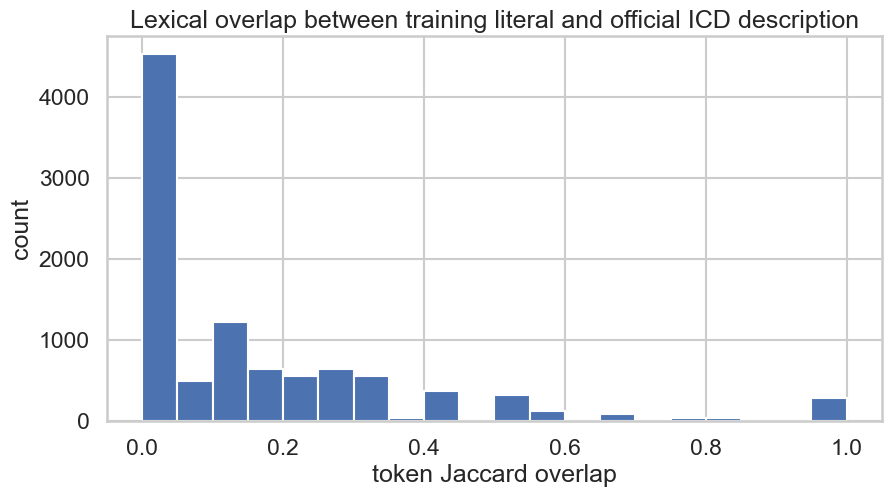

In [10]:

plt.figure(figsize=(10, 5))
plt.hist(known_catalog["token_jaccard"].dropna(), bins=20)
plt.title("Lexical overlap between training literal and official ICD description")
plt.xlabel("token Jaccard overlap")
plt.ylabel("count")
plt.show()



### Interpretation

The official description helps us because it ties each code to a standardized meaning, but it is often **lexically different** from the observed literal.

So the ICD catalog is best used as:

- a **knowledge source for candidates and interpretation**,
- a way to infer whether a code is diagnosis (`D`) or procedure (`P`),
- and a way to exploit code structure.

It is **not** enough to simply compare raw literals against raw descriptions.



## 6. Code structure: diagnosis, procedure and hierarchy

At this point we already know the problem is noisy.  
Now we ask whether the **codes themselves** provide exploitable structure.

This matters because if the code space is hierarchical, then a model can use that structure:
- candidate generation by prefix,
- diagnosis vs procedure separation,
- error analysis at coarse-grained levels before fine-grained levels.


,type,count
0,D,101246
1,P,78496


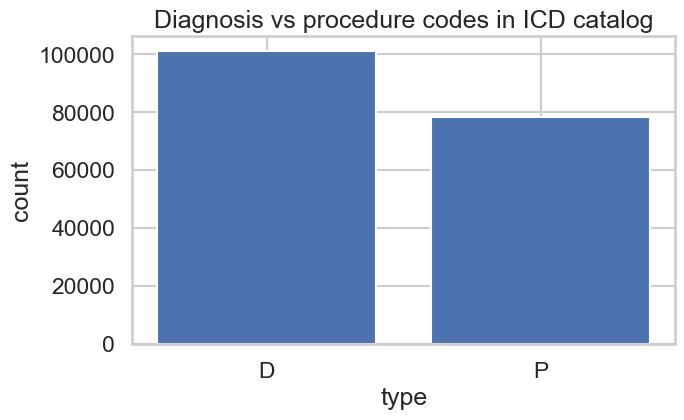

In [11]:

catalog_dp = icd_catalog["D_P"].value_counts().rename_axis("type").reset_index(name="count")
display(catalog_dp)

plt.figure(figsize=(7, 4))
plt.bar(catalog_dp['type'], catalog_dp['count'])
plt.title('Diagnosis vs procedure codes in ICD catalog')
plt.xlabel('type')
plt.ylabel('count')
plt.show()


,code_type,D_P,count
0,alphanumeric,D,7932
2,numeric,P,1579
1,alphanumeric,P,432


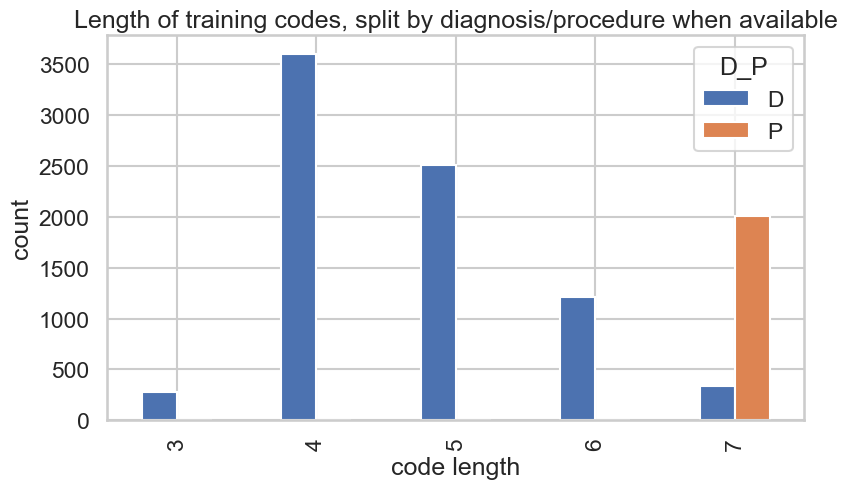

In [12]:

merged["code_len"] = merged["Code"].astype(str).str.len()
merged["code_type"] = merged["Code"].astype(str).str.match(r"^[A-Z]").map({True: "alphanumeric", False: "numeric"})

code_structure = (
    merged.groupby(["code_type", "D_P"])["Code"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(code_structure)
ct = merged.pivot_table(index='code_len', columns='D_P', values='Code', aggfunc='count', fill_value=0)
ct.plot(kind='bar', figsize=(9,5))
plt.title('Length of training codes, split by diagnosis/procedure when available')
plt.xlabel('code length')
plt.ylabel('count')
plt.show()



### What this tells us

We see a mixed situation:

- some training codes are clearly linked to diagnosis/procedure entries in the catalog,
- others do not align cleanly with the catalog,
- diagnosis and procedure codes have different structural patterns.

This is useful for our proposal: **a hierarchy-aware or type-aware pipeline makes sense**, but it must be robust to imperfect catalog coverage.



## 7. A first classical baseline: retrieval instead of full-blown classification

Now that we understand the data, we can finally test a first method.

### Why retrieval first?
Because the EDA suggests the problem is dominated by:

- short literals,
- lexical variation,
- abbreviations,
- synonyms,
- and repeated or near-repeated forms.

That is exactly the setting where a strong **classical retrieval baseline** can be very informative.

We test a **TF-IDF character n-gram nearest-neighbor baseline**.  
Character n-grams are a good fit because they are robust to:
- small spelling changes,
- abbreviations,
- accents,
- and partial overlap.


In [13]:

def retrieval_baseline(df, random_state=42, strict_by_literal=True, top_k=5):
    work = df.copy()
    work["norm_literal"] = work["Literal"].map(normalize_text)

    if strict_by_literal:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
        train_idx, test_idx = next(splitter.split(work, groups=work["norm_literal"]))
        setting = "strict split by normalized literal"
    else:
        train_idx, test_idx = train_test_split(
            np.arange(len(work)), test_size=0.2, random_state=random_state
        )
        setting = "random split"

    train = work.iloc[train_idx].copy()
    test = work.iloc[test_idx].copy()

    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))
    X_train = vectorizer.fit_transform(train["norm_literal"])
    X_test = vectorizer.transform(test["norm_literal"])

    sims = linear_kernel(X_test, X_train)
    top_idx = np.argpartition(-sims, kth=top_k-1, axis=1)[:, :top_k]
    row_idx = np.arange(sims.shape[0])[:, None]
    top_idx = top_idx[row_idx, np.argsort(-sims[row_idx, top_idx], axis=1)]

    train_codes = train["Code"].to_numpy()
    pred_top1 = train_codes[top_idx[:, 0]]
    pred_topk = train_codes[top_idx]

    return {
        "setting": setting,
        "n_train": len(train),
        "n_test": len(test),
        "acc@1": (pred_top1 == test["Code"].to_numpy()).mean(),
        "hit@5": np.any(pred_topk == test["Code"].to_numpy()[:, None], axis=1).mean(),
        "examples": pd.DataFrame({
            "literal": test["Literal"].values[:10],
            "gold_code": test["Code"].values[:10],
            "pred_code_top1": pred_top1[:10],
        })
    }

strict_results = retrieval_baseline(codification, strict_by_literal=True)
random_results = retrieval_baseline(codification, strict_by_literal=False)

baseline_table = pd.DataFrame([
    {k: v for k, v in strict_results.items() if k != "examples"},
    {k: v for k, v in random_results.items() if k != "examples"},
])

display(baseline_table.style.format({"acc@1": "{:.1%}", "hit@5": "{:.1%}"}))


,setting,n_train,n_test,acc@1,hit@5
0,strict split by normalized literal,10954,2746,24.3%,49.0%
1,random split,10960,2740,38.1%,63.9%



### Why we evaluated in two ways

This comparison is important.

- **Random split** is optimistic because the same literal or almost the same literal can appear in both train and test.
- **Strict split by normalized literal** is harder and more realistic for unseen forms.

So the gap between these two results is itself an insight:
it measures how much the system is relying on memorization versus genuine generalization.


In [14]:

display(strict_results["examples"])


,literal,gold_code,pred_code_top1
0,miocardiopatía dilatada,I420,I420
1,HTA irc 6,Y831,40390
2,Crisis febriles atípicas,R5600,R509
3,ECOGRAFIA TRANVAGINAL,BU4CZZZ,BU46ZZZ
4,Nódulo vocales,J382,J382
5,RX abdomen,BW00ZZZ,8819
6,Indometacina rectal,3E0H73Z,0D9P70Z
7,detorsión testicular derecho,0VN90ZZ,0VN90ZZ
8,Asma part,J45909,49390
9,lma,98613,1749



## 8. What baseline results mean for the proposal

The retrieval baseline is not the final system, but it already teaches us a lot:

1. **A classical baseline is viable**  
   Even without deep learning, short clinical literals can be matched surprisingly well using lexical similarity.

2. **Memorization helps, but unseen variation is the real challenge**  
   The strict split is much harder, which confirms that surface variation and ambiguity are central.

3. **Top-5 matters**  
   If hit@5 is much better than acc@1, then the candidate generator is useful, but reranking / disambiguation is still needed.

This naturally leads to a pipeline design.



## 9. Proposed methods for the project

Based on the EDA, the literature on automated ICD coding, and the constraints of this specific dataset, our proposal is to start with **classical, interpretable baselines** before attempting anything more complex.

### Method 1 - Strong lexical retrieval baseline
**Pipeline**
1. text normalization,
2. exact-match dictionary,
3. TF-IDF character n-gram retrieval over training literals,
4. return top-k candidate codes.

**Why it makes sense here**
- inputs are short,
- spelling variation matters,
- abbreviations matter,
- exact repetitions exist,
- retrieval is easy to interpret.

### Method 2 - Retrieval + SVM classification
After generating a small candidate set, perform final disambiguation using a linear SVM on character n-grams:
- Use character n-grams (3-5) as input features,
- Train an SVM model to predict the specific ICD code within the candidate set.

**Why this is the most promising next step**
The EDA showed that the main difficulty is not finding vaguely similar codes; it is **choosing the correct one among plausible alternatives**. A classical ML model like an SVM is robust to noise and very efficient with sparse n-gram features.

### Method 3 - Classical discriminative baseline for comparison
Use a linear model such as:
- one-vs-rest linear SVM, or
- logistic regression on word + character n-grams.

**Why we want it**
This gives us a proper classifier baseline and lets us compare:
- pure retrieval,
- pure classification,
- hybrid retrieval + reranking.

### What we do not prioritize first
We do **not** start with HMMs, CRFs or parsing-based methods, because those are designed for sequence labeling or syntactic structure, while this dataset is dominated by short standalone literals.  
They are very useful in NLP, but not the most natural first tool for this particular problem.



## 10. Final conclusions for the follow-up

At this point we can answer the follow-up clearly.

### We now understand the task
This is best interpreted as a **clinical literal codification / normalization** problem, not as full long-document ICD coding.

### We now understand the data
The dataset mixes:
- repeated literals,
- short noisy phrases,
- abbreviations,
- ambiguous forms,
- and partial alignment with a larger ICD catalog.

### We now understand the main challenges
The main challenges are:
1. surface variation,
2. literal-to-code ambiguity,
3. code-to-literal synonymy,
4. imperfect alignment between observed literals and official terminology,
5. generalizing to unseen but similar literals.

### We now have a justified first plan
Our first implementation should be a **hybrid classical system**:

- **Step 1:** normalization + exact lookup  
- **Step 2:** TF-IDF character n-gram retrieval  
- **Step 3:** SVM model trained on character n-grams to perform the final disambiguation and assignment  

This proposal is simple, interpretable, aligned with the EDA, and strong enough to function as a serious baseline for the next milestone.

---

## References used to guide the proposal
- The course project brief and follow-up instructions.
- The ICD coding survey provided with the project.
- Shared-task literature on clinical coding in Spanish and ICD coding more broadly.
- General Jupyter guidance on computational narratives: the notebook should explain the reasoning, not only show plots.

This is why the notebook is organized as a sequence of decisions:  
**what we learned -> why it matters -> what we do next.**
